The cell below contains a helper function I put together to better understand the generic rotation question proposed in the theory portion of the assignment. I include it here as it helped to contribute to my understanding of the transformation applied. 

In [2]:
import numpy as np
import qutip as qt
from IPython.display import display, clear_output

def rot_gate(k: int):
    omega = 2 * np.pi / (2 ** k)
    return np.array([[1, 0], [0, np.exp(1j * omega)]])

def generic_state(alpha: float, beta: float) -> qt.Qobj:
    norm = np.sqrt(abs(alpha)**2 + abs(beta)**2)
    alpha /= norm
    beta /= norm
    return qt.Qobj([[alpha], [beta]])

# plot the transformation rot_gate on generic_state in the Bloch sphere, include a slider to change k
def plot_rot_gate_on_bloch_sphere(alpha: float, beta: float):
    from qutip import Bloch
    import matplotlib.pyplot as plt
    from ipywidgets import IntSlider, VBox, interactive_output

    def _render(k):
        # create a fresh figure for each render so output updates cleanly
        fig = plt.figure()
        bloch = Bloch(fig=fig)
        state = generic_state(alpha, beta)
        new_state = qt.Qobj(rot_gate(k)) * state
        bloch.add_states([state, new_state])
        bloch.make_sphere()
        display(fig)
        plt.close(fig)
        
        # calculate and display the angle between states using overlap()
        overlap = state.overlap(new_state)
        angle = np.arccos(np.clip(np.abs(overlap), -1.0, 1.0))
        print(f"Angle between original and transformed state: {angle/np.pi:.2f} π radians")

    slider = IntSlider(value=1, min=1, max=10, step=1, description='k')
    out = interactive_output(_render, {'k': slider})
    display(VBox([slider, out]))


if __name__ == "__main__": 
    plot_rot_gate_on_bloch_sphere(1, 1)

# Assignment 1 - Programming


Circuit Composer

Learning outcomes:

- Explore Qiskit Composer
- Initialize qubit states and apply single and multi-qubit gates
- Understand and interpret the results of a quantum circuit

In a web browser, explore the Qiskit Circuit Composer https://quantum.ibm.com/composer/ by building a few circuits using the gates introduced in class. Report your findings in a Jupyter Notebook. Insert Qiskit composer screenshots and insert them into your notebook.

(P1)

- Initialize a circuit with two qubits
- Apply the Hadamard gate to the first qubit
- Apply the CNOT gate to the second qubit (controlled by the first qubit)
- What is the state vector when the circuit is initialized with |00⟩, and |10⟩?
- Make a measurement on both qubits. What is the probability of observing 00, 01, 10, and 11 for each of the initializations?

Note that the statevector (P1-3) needs to be provided before measurement.

(P2)

Use barriers (i.e., visual comments) to delineate different circuit parts for a two-qubit circuit with the following sequence of gates for an initialization of |00⟩:

- Apply Hadamard gates to both qubits
- Create a barrier
- Apply the CNOT gate with the first qubit as the control qubit and the second qubit as the target qubit
- Create a barrier
- For each barrier, give the qubit(s) state in Dirac notation and, in your own words, describe these qubit(s) states.
- What is the final statevector?



Statevector for input |00>:


<IPython.core.display.Latex object>

Statevector for input |10>:


<IPython.core.display.Latex object>

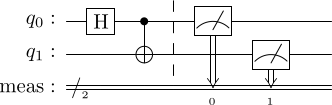

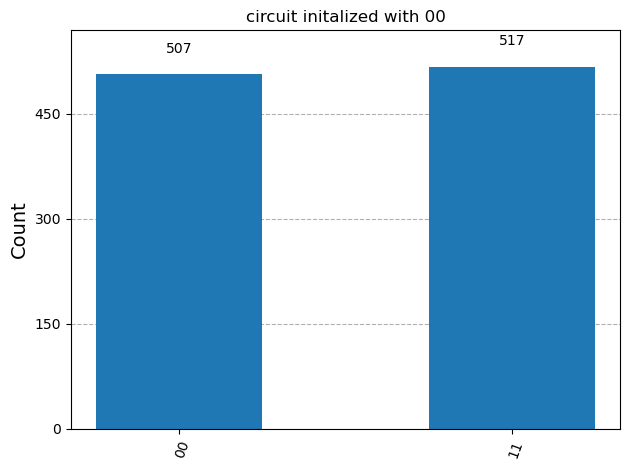

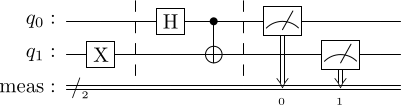

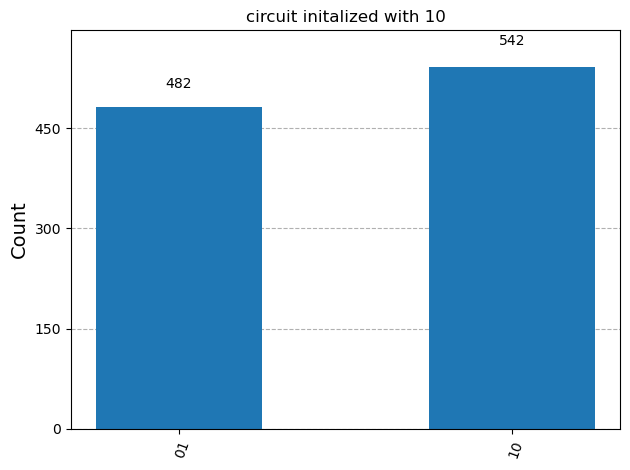

In [ ]:
# Q1

from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi



# initalize a circuit with 2 qubits
circuit = QuantumCircuit(2)
# apply a H gate to qubit 0
circuit.h(0)
# apply a CNOT gate with control qubit 0 and target qubit 1
circuit.cx(0, 1)


# simulate the circuit on input |00> and |10>, and obtain statevectors. 

initalize_state = Statevector.from_label('00')
final_state = initalize_state.evolve(circuit)
print('Statevector for input |00>:')
display(final_state.draw(output='latex'))

initalize_state = Statevector.from_label('10')
final_state = initalize_state.evolve(circuit)
print('Statevector for input |10>:')
display(final_state.draw(output='latex'))

# add measurements to the circuit and simulate it -- report the outputs. 
circuit.measure_all()
display(circuit.draw(output='latex'))
sim = AerSimulator()
transpiled_circuit = transpile(circuit, sim)
result = sim.run(transpiled_circuit).result()
counts = result.get_counts(transpiled_circuit)

display(plot_histogram(counts, title='circuit initalized with 00'))

# we can also do this again with the circuit initalized to |10> 
circuit10 = QuantumCircuit(2)
circuit10.x(1)
circuit10.barrier()
# add the operations we did above onto this circuit now. 
circuit10 = circuit10.compose(circuit)
display(circuit10.draw(output='latex'))
transpiled_circuit10 = transpile(circuit10, sim)
result10 = sim.run(transpiled_circuit10).result()
counts10 = result10.get_counts(transpiled_circuit10)

display(plot_histogram(counts10, title='circuit initalized with 10'))

Statevector for input |00>, at the first barrier:


<IPython.core.display.Latex object>

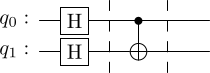

Statevector for input |00>, at the second barrier (also our final statevector):


<IPython.core.display.Latex object>

In [19]:
# P2
"""
Use barriers (i.e., visual comments) to delineate different circuit parts for a two-qubit circuit with the following sequence of gates for an initialization of |00⟩:

- Apply Hadamard gates to both qubits
- Create a barrier
- Apply the CNOT gate with the first qubit as the control qubit and the second qubit as the target qubit
- Create a barrier
- For each barrier, give the qubit(s) state in Dirac notation and, in your own words, describe these qubit(s) states.
- What is the final statevector?
"""

circuit_p2 = QuantumCircuit(2)
# input state 00 is implied upon initalization

# apply H to both qubits
circuit_p2.h(0)
circuit_p2.h(1)

# create a barrier
circuit_p2.barrier()

# output the statevector at this point.
sv = Statevector.from_label('00').evolve(circuit_p2)
print('Statevector for input |00>, at the first barrier:')
display(sv.draw(output='latex'))



# apply the CNOT gate
circuit_p2.cx(0, 1)     # This shouldn't change the state because we are essentially just changing the order (that is |10> and |11> switch) of an equally weighted superpostion. Because these amplitudes are equal, we should expect to see no apparent change in the statevector. 
circuit_p2.barrier()

display(circuit_p2.draw(output='latex'))

# output the statevector on input |00> 
sv = Statevector.from_label('00').evolve(circuit_p2)
print('Statevector for input |00>, at the second barrier (also our final statevector):')
display(sv.draw(output='latex'))

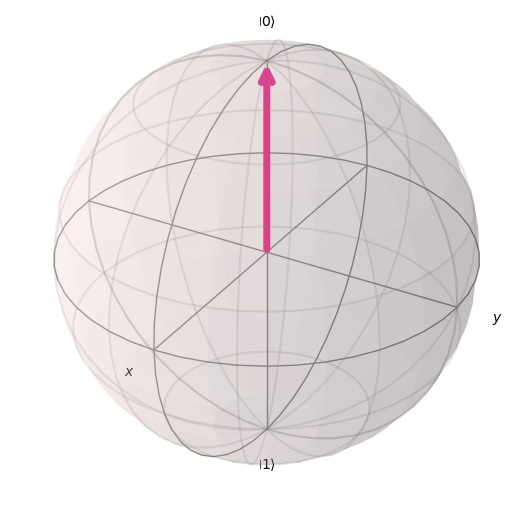

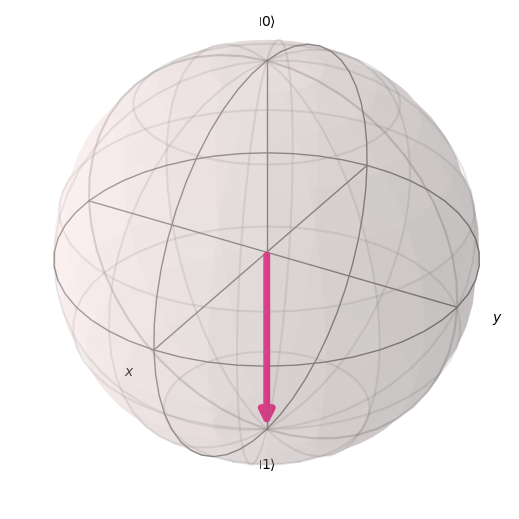

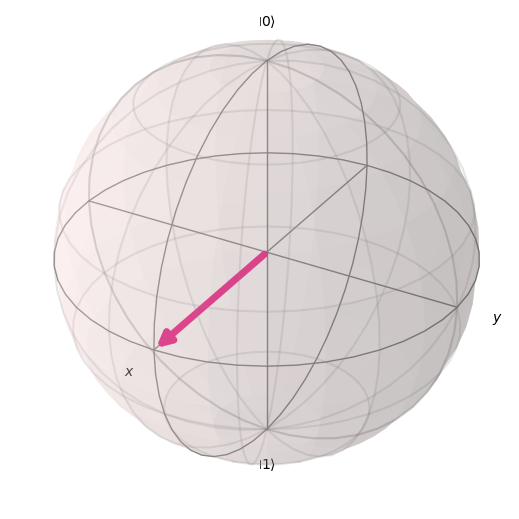

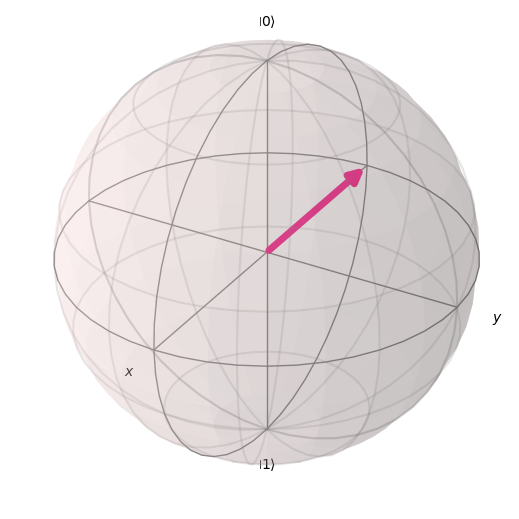

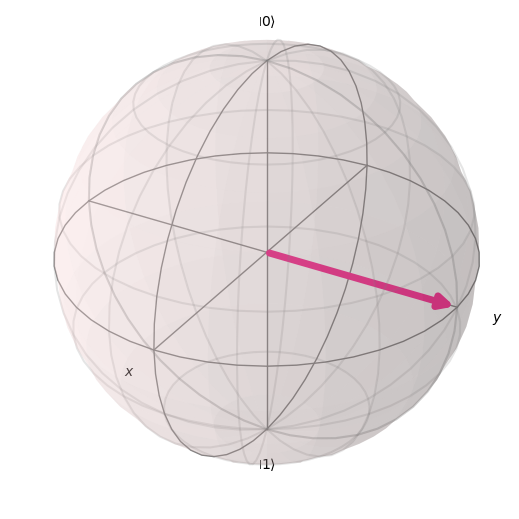

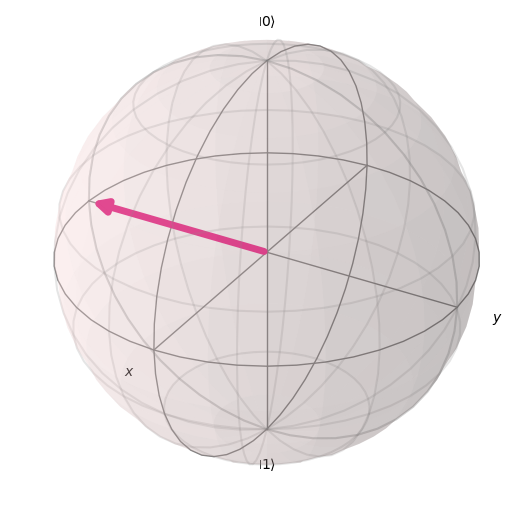

In [ ]:
# Q2

# use qiskit.visualization.plot_bloch_vector to plot basis states. 
# in my opinion we should really use QuTiP for this, it has much better features for plotting on the Bloch sphere, like the Bloch3d class. 

from qiskit.visualization import plot_bloch_vector as plot

# `plot_bloch_vector` accepts an array of 3 dimensions: [x, y, z], and plots the state on the Bloch sphere. 
# we could also pass in a statevector instead but I mean this is by far the fastest way of doing this


# plot |0>
display(plot([0,0,1]))


# plot |1>
display(plot([0,0,-1]))

# plot |+> 
display(plot([1, 0, 0]))

# plot |-> 
display(plot([-1, 0, 0]))

# plot |i +> 
display(plot([0, 1, 0]))

# plot |i -> 
display(plot([0, -1, 0]))


In [ ]:
# Q3 - Superdense Coding in Pennylane

"""


Learning Outcomes

    Understand Superdense Coding
    Implement Superdense Coding in PennyLane

Superdense coding is a quantum communication protocol that enables the transmission of two classical bits by sending only a single qubit. It leverages the entanglement and quantum superposition principles, allowing for more efficient quantum information transfer between sender and receiver. Read and understand the the protocol from IBM's Quantum Learning Platform.
https://learning.quantum.ibm.com/course/basics-of-quantum-information/entanglement-in-action

Using PennyLane, implement a superdense coding protocol for a pair of entangled qubits. Create a quantum circuit that prepares an entangled state, encodes two classical bits, and then measures the received qubit.

    What is the success probability of retrieving the correct classical bits?
    What happens when the entangled pair that is shared between the two parties is changed to |𝜓+⟩=1/sqrt(2) \cdot (|01⟩+|10⟩)?

Please submit your code as a Jupyter Notebook (.ipynb file) containing an implementation of the superdense coding protocol.

"""

# A very helpful resource for this assignment is section 2.3 of Nielsen and Chuang [1].
# [1] M. A. Nielsen, Quantum computation and quantum information. Cambridge ; Cambridge University Press, 2000.


import pennylane as qml
import numpy as np

dev = qml.device("default.qubit", wires=2)


@qml.qnode(dev)
def superdense_coding(bits: str):
    """
    Superdense coding protocol.
    
    Args:
        bits: Two classical bits as a string ('00', '01', '10', or '11')
    
    Returns:
        Probabilities of measuring each basis state
    """
    if bits not in ['00', '01', '10', '11']:
        raise ValueError('bits must be one of: [\'00\', \'01\', \'10\', \'11\']')
    
    # Step 1: Create Bell pair (entanglement)
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    
    # Apply a barrier for clarity.
    qml.Barrier()

    # Step 2: Alice encodes her bits on qubit 0
    if bits == '01':
        qml.PauliZ(wires=0)
    elif bits == '10':
        qml.PauliX(wires=0)
    elif bits == '11':
        qml.PauliX(wires=0)
        qml.PauliZ(wires=0)
    # '00' case: apply nothing (Identity)
    
    # Apply a barrier for clarity. 
    qml.Barrier()

    # Step 3: Bob performs Bell basis measurement
    qml.CNOT(wires=[0, 1])
    qml.Hadamard(wires=0)
    
    # Return measurement probabilities
    return qml.probs(wires=[0, 1])


# Test the protocol
print("Testing Superdense Coding Protocol:")
print("=" * 60)

for bits in ['00', '01', '10', '11']:
    # Draw the circuit
    print(f"\nCircuit for encoding bits: {bits}")
    print(qml.draw(superdense_coding)(bits))
    
    # Get results
    probs = superdense_coding(bits)
    
    print(f"Measurement probabilities: {probs}")
    print(f"Most likely outcome: {np.argmax(probs):02b}")
    print("-" * 60)

Testing Superdense Coding Protocol:

Circuit for encoding bits: 00
0: ──H─╭●──||──||─╭●──H─┤ ╭Probs
1: ────╰X──||──||─╰X────┤ ╰Probs
Measurement probabilities: [1. 0. 0. 0.]
Most likely outcome: 00
------------------------------------------------------------

Circuit for encoding bits: 01
0: ──H─╭●──||──Z──||─╭●──H─┤ ╭Probs
1: ────╰X──||─────||─╰X────┤ ╰Probs
Measurement probabilities: [0. 0. 1. 0.]
Most likely outcome: 10
------------------------------------------------------------

Circuit for encoding bits: 10
0: ──H─╭●──||──X──||─╭●──H─┤ ╭Probs
1: ────╰X──||─────||─╰X────┤ ╰Probs
Measurement probabilities: [0. 1. 0. 0.]
Most likely outcome: 01
------------------------------------------------------------

Circuit for encoding bits: 11
0: ──H─╭●──||──X──Z──||─╭●──H─┤ ╭Probs
1: ────╰X──||────────||─╰X────┤ ╰Probs
Measurement probabilities: [0. 0. 0. 1.]
Most likely outcome: 11
------------------------------------------------------------


In [37]:
# What happens when the entangled pair is changed to \psi^+> ? 
# well, let's adapt our superdense_coding function: 


@qml.qnode(dev)
def superdense_coding(bits: str):
    """
    Superdense coding protocol.
    
    Args:
        bits: Two classical bits as a string ('00', '01', '10', or '11')
    
    Returns:
        Probabilities of measuring each basis state
    """
    if bits not in ['00', '01', '10', '11']:
        raise ValueError('bits must be one of: [\'00\', \'01\', \'10\', \'11\']')
    
    # Step 0: Change input bits to generate a bell pair Psi^+ 
    qml.X(0)
    # recall that |10> generates bell state |Psi^+>. 

    # Step 1: Create Bell pair (entanglement)
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    
    # Apply a barrier for clarity.
    qml.Barrier()

    # Step 2: Alice encodes her bits on qubit 0
    if bits == '01':
        qml.PauliZ(wires=0)
    elif bits == '10':
        qml.PauliX(wires=0)
    elif bits == '11':
        qml.PauliX(wires=0)
        qml.PauliZ(wires=0)
    # '00' case: apply nothing (Identity)
    
    # Apply a barrier for clarity. 
    qml.Barrier()

    # Step 3: Bob performs Bell basis measurement
    qml.CNOT(wires=[0, 1])
    qml.Hadamard(wires=0)
    
    # Return measurement probabilities
    return qml.probs(wires=[0, 1])

# Test the protocol
print("Testing Superdense Coding Protocol (alternative bell pair):")
print("=" * 60)

for bits in ['00', '01', '10', '11']:
    # Draw the circuit
    print(f"\nCircuit for encoding bits: {bits}")
    print(qml.draw(superdense_coding)(bits))
    
    # Get results
    probs = superdense_coding(bits)
    
    print(f"Measurement probabilities: {probs}")
    print(f"Most likely outcome: {np.argmax(probs):02b}")
    print("-" * 60)

Testing Superdense Coding Protocol (alternative bell pair):

Circuit for encoding bits: 00
0: ──X──H─╭●──||──||─╭●──H─┤ ╭Probs
1: ───────╰X──||──||─╰X────┤ ╰Probs
Measurement probabilities: [0. 0. 1. 0.]
Most likely outcome: 10
------------------------------------------------------------

Circuit for encoding bits: 01
0: ──X──H─╭●──||──Z──||─╭●──H─┤ ╭Probs
1: ───────╰X──||─────||─╰X────┤ ╰Probs
Measurement probabilities: [1. 0. 0. 0.]
Most likely outcome: 00
------------------------------------------------------------

Circuit for encoding bits: 10
0: ──X──H─╭●──||──X──||─╭●──H─┤ ╭Probs
1: ───────╰X──||─────||─╰X────┤ ╰Probs
Measurement probabilities: [0. 0. 0. 1.]
Most likely outcome: 11
------------------------------------------------------------

Circuit for encoding bits: 11
0: ──X──H─╭●──||──X──Z──||─╭●──H─┤ ╭Probs
1: ───────╰X──||────────||─╰X────┤ ╰Probs
Measurement probabilities: [0. 1. 0. 0.]
Most likely outcome: 01
------------------------------------------------------------
